# Hyperparameter Tuning (9000-9179)

A reviewer asked for systematic HP tuning that was missing in the
original paper. This notebook loads the 180 HP-tuning experiments,
identifies the best value per HP per algorithm, and emits the
recommended HP configurations to apply to the rerun of the 4xxx /
5xxx / 6xxx main experiments.

**Design:**

- One-at-a-time (OAT) sweeps over 3 hyperparameters per algorithm,
  5 values per HP, 3 seeds per cell. Total = 4 x 3 x 5 x 3 = 180.
- Reduced compute scope per experiment (1 zone, spring only, 25 RL
  aggregations) - rankings are robust to this kind of reduction.
- Reward weights pinned at the recommended baseline (1, 1, 1) so the
  HP tuning is not confounded by reward shape.

**Selection criterion:** mean reward over the last N episodes (default
N=200) per (model, swept_HP, value), averaged across the 3 seeds. We
pick the HP value with the highest mean reward, breaking ties by
preferring values closer to existing defaults (Occam) and lower
across-seed std (stability).

**Output:** the final cell prints the recommended config snippet to
apply to each 4xxx template, and saves a CSV/JSON with the
recommendations under `paper_figure_generators/table_data/`.

### Imports

In [1]:
import sys
import os
import json
from pathlib import Path

sys.path.append(os.path.abspath('../'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from environment.data_loader import load_config_file

### Config

In [2]:
colors = {
    'DQN':       'darkorange',
    'REINFORCE': 'forestgreen',
    'CMA':       'turquoise',
    'CMA-ES':    'turquoise',
    'ODT':       'blueviolet',
}

# 9xxx HP tuning layout - kept in lock-step with
# generate_hp_tuning_experiments.py
SEEDS = [1234, 5555, 2020]
BLOCK_SIZE = 45                # 3 HPs * 5 values * 3 seeds
N_VALUES = 5
N_SEEDS  = 3

# (algorithm, [(hp_name, hp_path_in_config, values, centre)])
HP_BLOCKS = [
    ('DQN', [
        ('learning_rate',
         ('nn_hyperparameters', 'learning_rate'),
         [1.0e-5, 1.0e-4, 1.0e-3, 3.0e-3, 1.0e-2],
         1.0e-3),
        ('discount_factor',
         ('nn_hyperparameters', 'discount_factor'),
         [0.90, 0.95, 0.99, 0.995, 0.999],
         0.99),
        ('buffer_limit',
         ('nn_hyperparameters', 'buffer_limit'),
         [150, 500, 1500, 5000, 15000],
         1500),
    ]),
    ('REINFORCE', [
        ('learning_rate',
         ('nn_hyperparameters', 'learning_rate'),
         [1.0e-5, 1.0e-4, 1.0e-3, 3.0e-3, 1.0e-2],
         1.0e-3),
        ('discount_factor',
         ('nn_hyperparameters', 'discount_factor'),
         [0.90, 0.95, 0.99, 0.995, 0.999],
         0.99),
        ('layers_arch',
         ('nn_hyperparameters', 'layers'),
         [[32, 32], [64, 64], [128, 64, 64], [256, 128, 64], [512, 256, 128, 64]],
         [128, 64, 64]),
    ]),
    ('CMA', [
        ('initial_sigma',
         ('cma_parameters', 'initial_sigma'),
         [0.01, 0.05, 0.10, 0.30, 1.00],
         0.10),
        ('population_dimension',
         ('cma_parameters', 'population_dimension'),
         [10, 20, 40, 80, 160],
         20),
        ('max_generations',
         ('cma_parameters', 'max_generations'),
         [50, 100, 200, 400, 800],
         200),
    ]),
    ('ODT', [
        ('learning_rate',
         ('odt_hyperparameters', 'learning_rate'),
         [1.0e-5, 1.0e-4, 1.0e-3, 1.0e-2, 1.0e-1],
         1.0e-4),
        ('embed_dim',
         ('odt_hyperparameters', 'embed_dim'),
         [64, 128, 256, 512, 1024],
         512),
        ('n_layer',
         ('odt_hyperparameters', 'n_layer'),
         [1, 2, 4, 6, 8],
         4),
    ]),
]

START_EXP = 9000

METRICS_ROOT_CANDIDATES = [
    '../../../../storage_1/metrics',
    '/storage_1/metrics',
    '../metrics',
    '../_local_metrics',
]
def resolve_metrics_root():
    for r in METRICS_ROOT_CANDIDATES:
        if os.path.isdir(r):
            return r
    return None
METRICS_ROOT = resolve_metrics_root()
print(f'Metrics root: {METRICS_ROOT}')

Metrics root: ../../../../storage_1/metrics


### Helpers

In [3]:
def hp_exp_metadata(exp_num):
    """Return (algorithm, hp_name, value, seed) for a 9xxx experiment."""
    offset = exp_num - START_EXP
    if not (0 <= offset < 4 * BLOCK_SIZE):
        raise ValueError(f'Exp_{exp_num} outside 9000-9179 HP-tuning range')
    block_idx = offset // BLOCK_SIZE
    within_block = offset % BLOCK_SIZE
    algo, hps = HP_BLOCKS[block_idx]
    hp_idx = within_block // (N_VALUES * N_SEEDS)
    within_hp = within_block % (N_VALUES * N_SEEDS)
    hp_name, hp_path, values, centre = hps[hp_idx]
    v_idx = within_hp // N_SEEDS
    s_idx = within_hp % N_SEEDS
    return algo, hp_name, values[v_idx], SEEDS[s_idx]


def exp_paths(exp_num):
    if METRICS_ROOT is None:
        return None
    base = Path(METRICS_ROOT) / f'Exp_{exp_num}' / 'train'
    return {
        'base':    base,
        'agent':   base / 'metrics_agent_episode_level.csv',
        'station': base / 'metrics_station_episode_level.csv',
        'config':  Path('..') / 'experiments' / f'Exp_{exp_num}' / 'config.yaml',
    }


def load_exp(exp_num):
    p = exp_paths(exp_num)
    if p is None or not p['agent'].exists():
        return None
    a = pd.read_csv(p['agent'])
    algo, hp_name, value, seed = hp_exp_metadata(exp_num)
    a['exp_num']   = exp_num
    a['algorithm'] = algo
    a['hp_name']   = hp_name
    # value may be a list (REINFORCE layers); store as string for grouping
    a['hp_value']  = str(value) if isinstance(value, list) else value
    a['seed']      = seed
    return {'agent': a, 'meta': (algo, hp_name, value, seed)}

### Load all 9xxx HP-tuning experiments

In [4]:
ALL_EXPS = list(range(9000, 9180))
loaded = {}
missing = []
for n in ALL_EXPS:
    d = load_exp(n)
    if d is None:
        missing.append(n)
    else:
        loaded[n] = d
print(f'Loaded:  {len(loaded):>3} / {len(ALL_EXPS)} experiments')
print(f'Missing: {len(missing):>3}')
if missing:
    runs = []
    s = missing[0]; prev = s
    for n in missing[1:]:
        if n == prev + 1:
            prev = n
        else:
            runs.append((s, prev)); s = n; prev = n
    runs.append((s, prev))
    print('  ranges:', ', '.join(f'{a}-{b}' if a != b else str(a) for a, b in runs))

Loaded:   90 / 180 experiments
Missing:  90
  ranges: 9090-9179


### Per-experiment summary

For each loaded experiment, compute the mean reward over the last
N=200 episodes (the converged-region average) and per-seed std. This
is the metric we use to rank HP values.

In [5]:
LAST_N = 200

def summarise(exp_num, d):
    a = d['agent']
    algo, hp_name, value, seed = d['meta']
    pairs = a[['aggregation', 'episode']].drop_duplicates()
    last_pairs = pairs.tail(min(LAST_N, len(pairs)))
    a_tail = a.merge(last_pairs, on=['aggregation', 'episode'])
    return {
        'exp_num':         exp_num,
        'algorithm':       algo,
        'hp_name':         hp_name,
        'hp_value':        str(value) if isinstance(value, list) else value,
        'hp_value_sortkey': _sortkey(value),
        'seed':            seed,
        'reward_mean':     a_tail['reward'].mean(),
        'reward_std_within': a_tail['reward'].std(),
        'n_eps_used':      len(last_pairs),
    }

def _sortkey(v):
    """Stable numeric sort key for any HP value (list or scalar)."""
    if isinstance(v, list):
        return float(sum(v))   # total network capacity proxy
    return float(v)

if loaded:
    rows = [summarise(n, d) for n, d in loaded.items()]
    summary = pd.DataFrame(rows).sort_values(['algorithm', 'hp_name', 'hp_value_sortkey', 'seed']).reset_index(drop=True)
    print(f'Summary table: {len(summary)} experiments')
    display(summary.head(20))
else:
    summary = pd.DataFrame()
    print('No data loaded - downstream cells will be skipped until the 9xxx batch is rsync-ed onto this server.')

Summary table: 90 experiments


,exp_num,algorithm,hp_name,hp_value,hp_value_sortkey,seed,reward_mean,reward_std_within,n_eps_used
0,9030,DQN,buffer_limit,150,150.00,1234,-88.084493,3.984659,200
1,9032,DQN,buffer_limit,150,150.00,2020,-86.128749,4.391290,200
2,9031,DQN,buffer_limit,150,150.00,5555,-79.820459,4.214430,200
3,9033,DQN,buffer_limit,500,500.00,1234,-91.340737,4.061405,200
4,9035,DQN,buffer_limit,500,500.00,2020,-90.593551,3.769384,200
5,9034,DQN,buffer_limit,500,500.00,5555,-84.532960,3.656428,200
6,9036,DQN,buffer_limit,1500,1500.00,1234,-90.906195,3.306871,200
7,9038,DQN,buffer_limit,1500,1500.00,2020,-90.566135,3.935969,200
8,9037,DQN,buffer_limit,1500,1500.00,5555,-85.678153,4.711383,200
9,9039,DQN,buffer_limit,5000,5000.00,1234,-90.289902,2.771657,200


### Performance vs HP value (per algorithm, per HP)

Four rows (one per algorithm), three columns (one per swept HP).
Each subplot shows mean reward vs HP value with error bars across seeds.

Saved figures/hp_tuning_sweeps.png


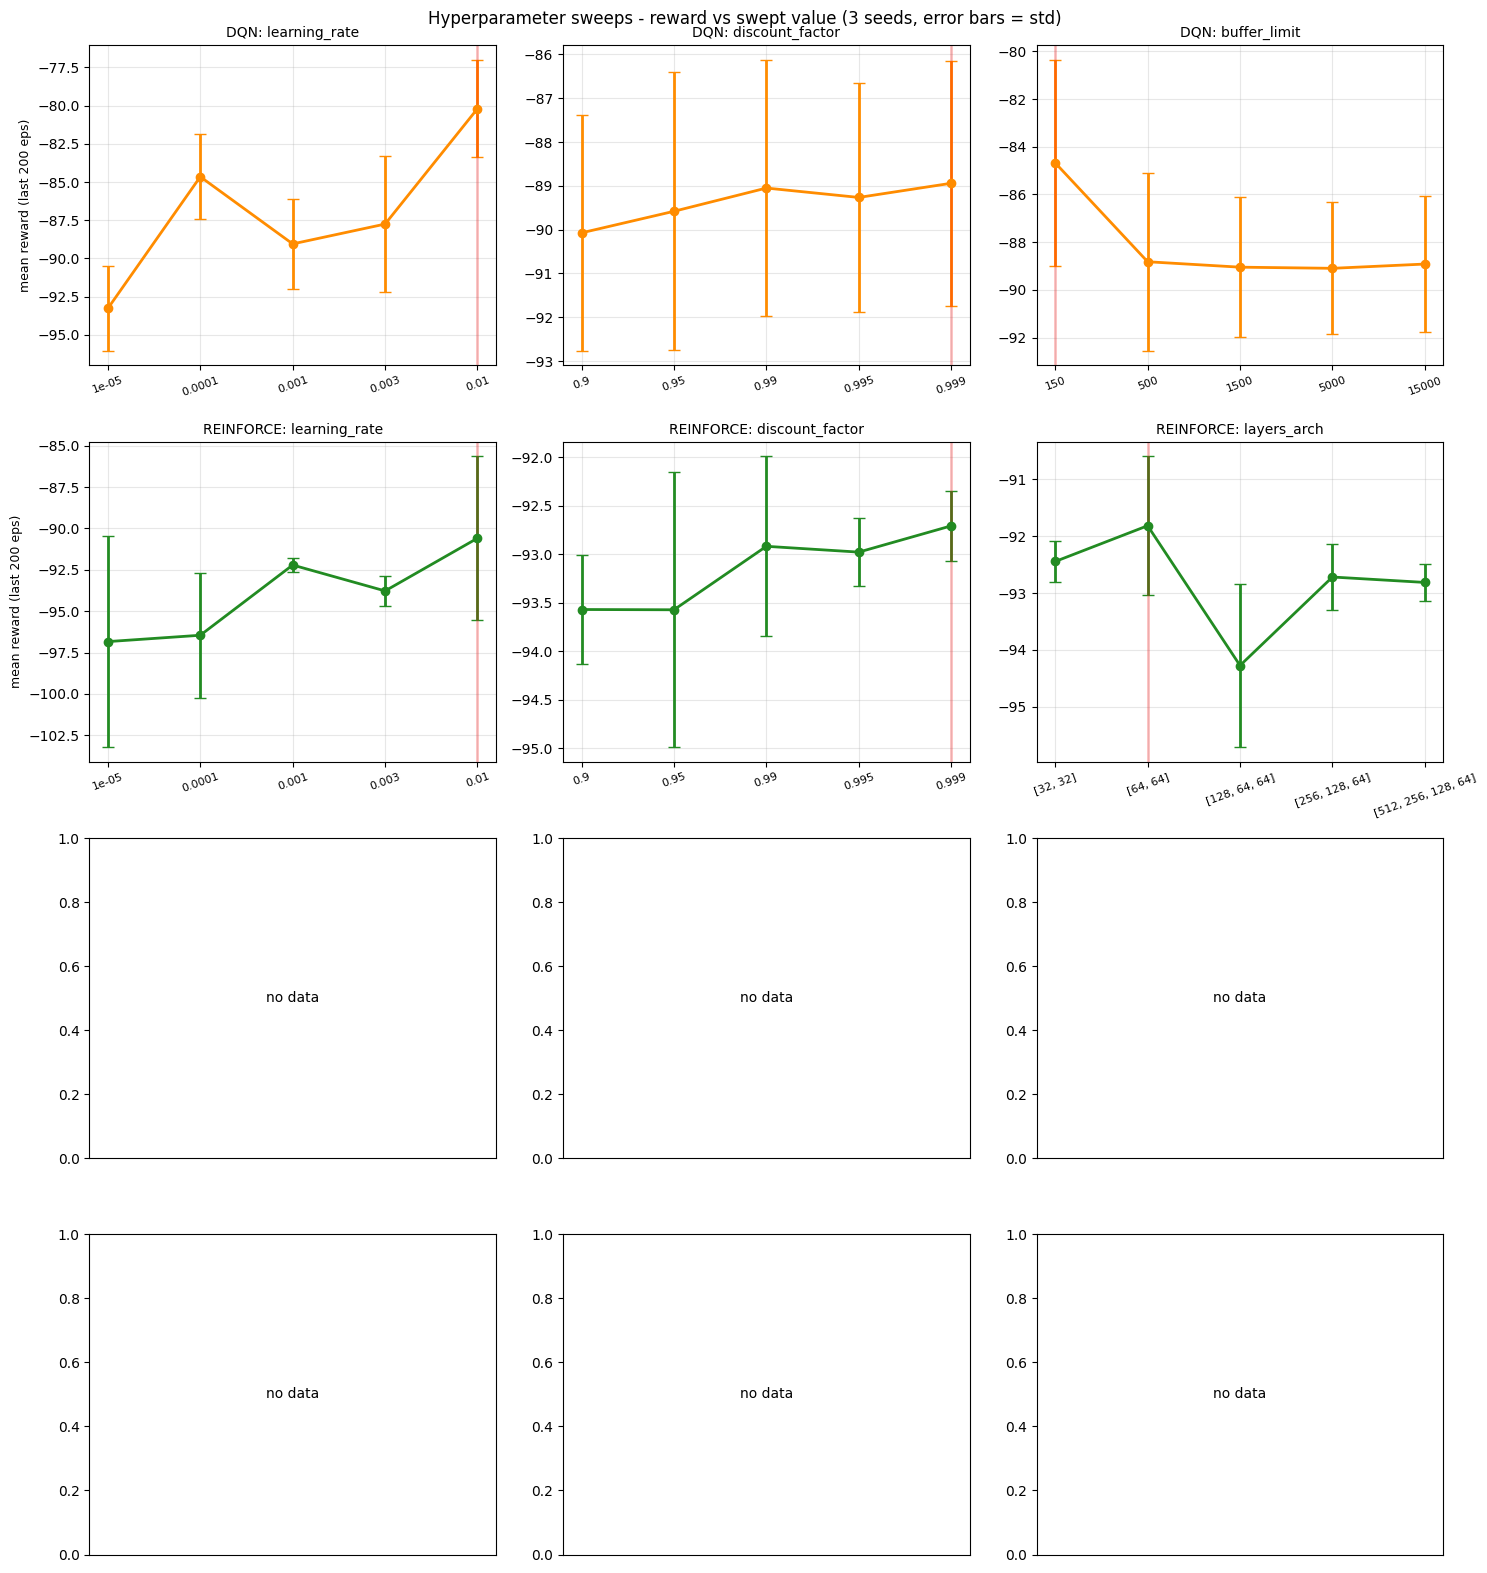

In [6]:
if not summary.empty:
    algos = [b[0] for b in HP_BLOCKS]
    fig, axes = plt.subplots(len(algos), 3, figsize=(15, 4 * len(algos)))
    for r, algo in enumerate(algos):
        hps_for_algo = [hp[0] for hp in dict(HP_BLOCKS)[algo]]
        for c, hp_name in enumerate(hps_for_algo):
            ax = axes[r, c] if len(algos) > 1 else axes[c]
            sub = summary[(summary['algorithm'] == algo) & (summary['hp_name'] == hp_name)]
            if sub.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                continue
            agg = (sub.groupby(['hp_value', 'hp_value_sortkey'])['reward_mean']
                      .agg(['mean', 'std', 'count'])
                      .reset_index()
                      .sort_values('hp_value_sortkey'))
            xs = np.arange(len(agg))
            ax.errorbar(xs, agg['mean'], yerr=agg['std'],
                        marker='o', lw=2, capsize=4, color=colors[algo])
            ax.set_xticks(xs)
            ax.set_xticklabels([str(v) for v in agg['hp_value']], rotation=20, fontsize=8)
            # Highlight best
            best_idx = int(agg['mean'].idxmax()) if not agg['mean'].isna().all() else None
            if best_idx is not None:
                best_pos = list(agg.index).index(best_idx)
                ax.axvline(best_pos, color='red', alpha=0.25, lw=2)
            ax.set_title(f'{algo}: {hp_name}', fontsize=10)
            ax.grid(alpha=0.3)
            if c == 0:
                ax.set_ylabel('mean reward (last 200 eps)', fontsize=9)
    fig.suptitle('Hyperparameter sweeps - reward vs swept value (3 seeds, error bars = std)', fontsize=12)
    plt.tight_layout()
    out = Path('figures') / 'hp_tuning_sweeps.png'
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=180, bbox_inches='tight')
    print(f'Saved {out}')
    plt.show()

### Recommendations: best value per HP per algorithm

For each (algorithm, swept HP), pick the value with the highest
seed-averaged final reward. Ties broken by preferring the value
closer to the existing default (Occam) and then lower across-seed std.

In [7]:
def recommend(summary, hp_blocks):
    rows = []
    for algo, hps in hp_blocks:
        for hp_name, hp_path, values, centre in hps:
            sub = summary[(summary['algorithm'] == algo) & (summary['hp_name'] == hp_name)]
            if sub.empty:
                rows.append({
                    'algorithm': algo, 'hp_name': hp_name,
                    'best_value': None, 'best_reward': np.nan, 'best_std': np.nan,
                    'centre_value': str(centre) if isinstance(centre, list) else centre,
                    'note': 'no data',
                })
                continue
            agg = (sub.groupby(['hp_value','hp_value_sortkey'])['reward_mean']
                      .agg(mean='mean', std='std', count='count')
                      .reset_index())
            best_mean = agg['mean'].max()
            # Tolerance ties: anything within 1 std of best
            tol = agg.loc[agg['mean'].idxmax(), 'std']
            tol = tol if not np.isnan(tol) else 0
            tie_mask = agg['mean'] >= (best_mean - tol)
            ties = agg[tie_mask].copy()
            # Tie-break: prefer closer to centre, then lower std
            centre_sk = float(sum(centre)) if isinstance(centre, list) else float(centre)
            ties['dist_to_centre'] = (ties['hp_value_sortkey'] - centre_sk).abs()
            ties = ties.sort_values(['dist_to_centre', 'std', 'mean'], ascending=[True, True, False])
            best = ties.iloc[0]
            rows.append({
                'algorithm':   algo,
                'hp_name':     hp_name,
                'best_value':  best['hp_value'],
                'best_reward': float(best['mean']),
                'best_std':    float(best['std']) if not np.isnan(best['std']) else None,
                'centre_value': str(centre) if isinstance(centre, list) else centre,
                'note':        'unique best' if tie_mask.sum() == 1 else f'{tie_mask.sum()} tied (Occam-broken)',
            })
    return pd.DataFrame(rows)

if not summary.empty:
    recs = recommend(summary, HP_BLOCKS)
    print('Per-HP recommendations:')
    display(recs)

Per-HP recommendations:


,algorithm,hp_name,best_value,best_reward,best_std,centre_value,note
0,DQN,learning_rate,0.01,-80.197364,3.190778,0.001,unique best
1,DQN,discount_factor,0.99,-89.050161,2.925190,0.99,5 tied (Occam-broken)
2,DQN,buffer_limit,500.0,-88.822416,3.733517,1500,3 tied (Occam-broken)
3,REINFORCE,learning_rate,0.001,-92.209951,0.424762,0.001,3 tied (Occam-broken)
4,REINFORCE,discount_factor,0.99,-92.919769,0.928339,0.99,3 tied (Occam-broken)
5,REINFORCE,layers_arch,"[64, 64]",-91.815845,1.221545,"[128, 64, 64]",4 tied (Occam-broken)
6,CMA,initial_sigma,None,NaN,NaN,0.1,no data
7,CMA,population_dimension,None,NaN,NaN,20,no data
8,CMA,max_generations,None,NaN,NaN,200,no data
9,ODT,learning_rate,None,NaN,NaN,0.0001,no data


### Consolidated config snippets

Apply the recommendations to the four template configs (Exp_4000,
Exp_4036, Exp_4072, Exp_4108). These snippets can be patched into all
4xxx, 5xxx, and 6xxx configs before re-running the main experiments.

In [8]:
def _coerce(v, original):
    """Cast back to the original Python type so YAML serialises clean."""
    if isinstance(original, list):
        try:
            return json.loads(v.replace("'", '"'))
        except Exception:
            return original
    if isinstance(original, bool):
        return bool(v)
    if isinstance(original, int):
        try:
            return int(float(v))
        except Exception:
            return original
    try:
        return float(v)
    except Exception:
        return v

if not summary.empty:
    output = {}
    for algo, hps in HP_BLOCKS:
        rec_algo = recs[recs['algorithm'] == algo]
        block_name = {
            'DQN':       'nn_hyperparameters',
            'REINFORCE': 'nn_hyperparameters',
            'CMA':       'cma_parameters',
            'ODT':       'odt_hyperparameters',
        }[algo]
        snippet = {block_name: {}}
        for hp_name, hp_path, values, centre in hps:
            row = rec_algo[rec_algo['hp_name'] == hp_name]
            if row.empty or row.iloc[0]['best_value'] is None:
                continue
            v = row.iloc[0]['best_value']
            snippet[block_name][hp_path[-1]] = _coerce(v, centre)
        output[algo] = snippet
    print(json.dumps(output, indent=2, default=str))
    out = Path('table_data') / 'hp_tuning_recommendations.json'
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(output, indent=2, default=str))
    print(f'\nSaved {out}')
    # Also save the per-HP table as CSV
    recs.to_csv(Path('table_data') / 'hp_tuning_recommendations.csv', index=False)
    print(f'Saved table_data/hp_tuning_recommendations.csv')

{
  "DQN": {
    "nn_hyperparameters": {
      "learning_rate": 0.01,
      "discount_factor": 0.99,
      "buffer_limit": 500
    }
  },
  "REINFORCE": {
    "nn_hyperparameters": {
      "learning_rate": 0.001,
      "discount_factor": 0.99,
      "layers": [
        64,
        64
      ]
    }
  },
  "CMA": {
    "cma_parameters": {}
  },
  "ODT": {
    "odt_hyperparameters": {}
  }
}

Saved table_data/hp_tuning_recommendations.json
Saved table_data/hp_tuning_recommendations.csv


### Apply recommendations to 4xxx / 5xxx / 6xxx configs

After running this notebook end-to-end, the recommendations are stored
in `table_data/hp_tuning_recommendations.json`. The block below patches
those values into every 4xxx, 5xxx, and 6xxx config (and 7xxx, 8xxx
too, since those are derived from the same templates). Run with
`apply = True` to actually write the configs. By default it dry-runs
and shows you what would change.

In [9]:
apply = False   # set to True to actually patch the configs

if not summary.empty and Path('table_data/hp_tuning_recommendations.json').exists():
    recs_data = json.loads(Path('table_data/hp_tuning_recommendations.json').read_text())

    # Determine each experiment's algorithm by reading its config
    import glob
    target_dirs = sorted(set(
        glob.glob('../experiments/Exp_4*') +
        glob.glob('../experiments/Exp_5*') +
        glob.glob('../experiments/Exp_6*') +
        glob.glob('../experiments/Exp_7*') +
        glob.glob('../experiments/Exp_8*')
    ))
    changes = 0
    for exp_dir in target_dirs:
        cfg_path = Path(exp_dir) / 'config.yaml'
        if not cfg_path.exists():
            continue
        import yaml
        cfg = yaml.safe_load(open(cfg_path))
        algo = cfg.get('algorithm_settings', {}).get('algorithm')
        if algo not in recs_data:
            continue
        snippet = recs_data[algo]
        local_changes = []
        for block, fields in snippet.items():
            cfg.setdefault(block, {})
            for k, v in fields.items():
                if cfg[block].get(k) != v:
                    local_changes.append(f'{block}.{k}: {cfg[block].get(k)!r} -> {v!r}')
                    cfg[block][k] = v
        if local_changes and apply:
            yaml.safe_dump(cfg, open(cfg_path, 'w'), sort_keys=True)
            changes += 1
        elif local_changes:
            print(f'{Path(exp_dir).name}: would change {local_changes[:3]}')
    if apply:
        print(f'\nPatched {changes} config files.')
    else:
        print(f'\n(dry run - set apply=True and re-run this cell to write)')

Exp_4000: would change ['nn_hyperparameters.learning_rate: 1e-05 -> 0.01', 'nn_hyperparameters.discount_factor: 0.999 -> 0.99', 'nn_hyperparameters.buffer_limit: 150 -> 500']
Exp_4001: would change ['nn_hyperparameters.learning_rate: 1e-05 -> 0.01', 'nn_hyperparameters.discount_factor: 0.999 -> 0.99', 'nn_hyperparameters.buffer_limit: 150 -> 500']
Exp_4002: would change ['nn_hyperparameters.learning_rate: 1e-05 -> 0.01', 'nn_hyperparameters.discount_factor: 0.999 -> 0.99', 'nn_hyperparameters.buffer_limit: 150 -> 500']
Exp_4003: would change ['nn_hyperparameters.learning_rate: 1e-05 -> 0.01', 'nn_hyperparameters.discount_factor: 0.999 -> 0.99', 'nn_hyperparameters.buffer_limit: 150 -> 500']
Exp_4004: would change ['nn_hyperparameters.learning_rate: 1e-05 -> 0.01', 'nn_hyperparameters.discount_factor: 0.999 -> 0.99', 'nn_hyperparameters.buffer_limit: 150 -> 500']
Exp_4005: would change ['nn_hyperparameters.learning_rate: 1e-05 -> 0.01', 'nn_hyperparameters.discount_factor: 0.999 -> 0.99